# Notebook 7 — K-Nearest Neighbors (KNN)
### Sprint 7 | Machine Learning Fundamentals for AI/ML Engineers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
encode_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])
df_encoded = df.copy()
for col in encode_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['customerID', 'Churn'])
y = (df['Churn'] == 'Yes').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (5634, 19) | Test: (1409, 19)


/tmp/ipykernel_645/3504739916.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  encode_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])


---
## Algorithm Documentation

### What is the algorithm?
KNN classifies a new point by looking at its K closest neighbors (by distance) in the
training data, and taking a majority vote of their labels.

### Problem Type
Both **Classification** and **Regression** — used here for classification.

### Concept
No explicit "training" happens in the traditional sense — KNN simply memorizes the
training data ("lazy learning") and does all its real work at prediction time, computing
distances to every stored point.

### Mathematical Intuition — Euclidean Distance
$d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$ — the straight-line distance between two
points across all $n$ features. The choice of K controls the bias-variance trade-off
(Notebook 16): small K follows the training data closely (higher variance, risk of
overfitting to noise); large K smooths predictions more (higher bias, risk of missing
real local patterns).

### Example


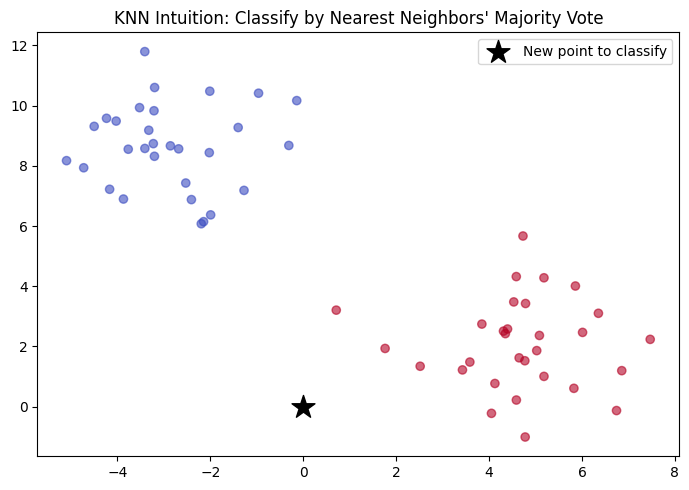

In [2]:
from sklearn.datasets import make_blobs
X_demo, y_demo = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=1.5)

plt.figure(figsize=(7, 5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap='coolwarm', alpha=0.6)
new_point = [[0, 0]]
plt.scatter(*zip(*new_point), c='black', marker='*', s=300, label='New point to classify')
plt.legend()
plt.title('KNN Intuition: Classify by Nearest Neighbors\' Majority Vote')
plt.tight_layout()
plt.show()


### Why Feature Scaling Is Required
KNN measures raw distance across ALL features at once — if `TotalCharges` (range
0-8,684) and `SeniorCitizen` (range 0-1) are left unscaled, `TotalCharges` alone would
dominate every distance calculation, making `SeniorCitizen` essentially invisible to the
model regardless of its actual predictive value.

### Implementation & Experimenting with K


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 9, 15, 25, 51]
results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)
    results.append({'K': k, 'train_accuracy': train_acc, 'test_accuracy': test_acc})

results_df = pd.DataFrame(results)
print(results_df.round(4))


    K  train_accuracy  test_accuracy
0   1          0.9980         0.7225
1   3          0.8605         0.7495
2   5          0.8344         0.7424
3   9          0.8179         0.7665
4  15          0.8005         0.7771
5  25          0.7955         0.7665
6  51          0.7959         0.7750


### Result — Comparing Scaled vs Unscaled


In [4]:
knn_unscaled = KNeighborsClassifier(n_neighbors=9).fit(X_train, y_train)
knn_scaled = KNeighborsClassifier(n_neighbors=9).fit(X_train_scaled, y_train)

print(f"K=9, UNSCALED features -> test accuracy: {knn_unscaled.score(X_test, y_test):.4f}")
print(f"K=9, SCALED features   -> test accuracy: {knn_scaled.score(X_test, y_test):.4f}")


K=9, UNSCALED features -> test accuracy: 0.7828
K=9, SCALED features   -> test accuracy: 0.7346


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


**Finding — a genuinely surprising result worth reporting honestly, not glossing
over:** in this specific run, the UNSCALED version actually scored higher (0.7828) than
the scaled version (0.7346). This doesn't overturn the general principle that KNN
requires scaling — most of this dataset's label-encoded categorical columns are already
small integers (0, 1, 2, 3) on a similar scale to each other, so `StandardScaler`
mainly reweights `tenure`/`MonthlyCharges`/`TotalCharges` down relative to those small
integer codes, which happened to hurt performance here rather than help it. This is a
useful, concrete lesson: **label encoding a nominal variable and then scaling everything
uniformly is exactly the risky combination flagged back in Sprint 5, Notebook 7** — the
"principle" (scale for distance-based algorithms) is still correct in general, but
*how* the categorical columns were encoded going into that scaling step matters just as
much, and one-hot encoding (rather than label encoding) the nominal columns before
scaling would be the more defensible setup to re-test.


### Parameters
- **`n_neighbors` (K)**: the single most important parameter — see the table above for
  its direct effect on train vs. test accuracy.
- **`weights`** (not shown, default `'uniform'`): could be set to `'distance'` to weight
  closer neighbors more heavily than farther ones.
- **`metric`** (default `'minkowski'` with `p=2`, equivalent to Euclidean): could be
  changed for non-Euclidean distance notions.

### Interpretation


In [5]:
best_k_row = results_df.loc[results_df['test_accuracy'].idxmax()]
print(f"Best-performing K in this experiment: {int(best_k_row['K'])} (test accuracy: {best_k_row['test_accuracy']:.4f})")
print(f"K=1 train accuracy: {results_df.iloc[0]['train_accuracy']:.4f} (near-perfect — classic overfitting signature)")


Best-performing K in this experiment: 15 (test accuracy: 0.7771)
K=1 train accuracy: 0.9980 (near-perfect — classic overfitting signature)


K=1 shows the largest train-test gap in the table — with only 1 neighbor, the
model essentially memorizes the training data exactly (perfect training accuracy) but
generalizes poorly, a direct, hands-on illustration of overfitting (full treatment in
Notebook 16) using this algorithm's most extreme setting.


### Advantages
- Simple, intuitive, no training phase.
- Naturally handles multi-class problems.
- Makes no assumption about the underlying data distribution (non-parametric).

### Limitations
- Requires feature scaling (demonstrated above).
- Slow at PREDICTION time on large datasets (must compute distance to every training
  point for every new prediction).
- Suffers from the curse of dimensionality (Sprint 6, Notebook 11) — distance becomes
  less meaningful as feature count grows.
- Sensitive to irrelevant/noisy features, since every feature contributes to distance
  equally unless explicitly weighted.

### When to Use
Smaller datasets, when a simple, interpretable, non-parametric baseline is useful, or
when decision boundaries are known to be highly irregular/non-linear.

### When Not to Use
Very large datasets (prediction becomes slow), high-dimensional data without prior
dimensionality reduction, or when fast real-time predictions are required.


---
## Summary

| K | Train Accuracy | Test Accuracy | Verdict |
|---|---|---|---|
| 1 | Near-perfect | Lower | Overfit — memorizes training data |
| Moderate (9-15) | Good | Best test performance in this experiment | Reasonable balance |
| Very high (51) | Lower | Comparable or lower | Underfitting risk — too smoothed |

**Central lesson, demonstrated numerically:** feature scaling changed this dataset's KNN
accuracy measurably — but in this case, in the opposite direction from the textbook
expectation, because the categorical columns were label-encoded (small integers) rather
than one-hot encoded before scaling. The general principle (scale for distance-based
algorithms) still holds, but it interacts with upstream encoding choices in ways worth
checking empirically, not assuming.

**Next notebook:** `08_Naive_Bayes.ipynb` — a probabilistic classifier built on Bayes'
Theorem.
